In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [ ]:
class AccidentPredictionPipeline:
    def __init__(self, csv_path):
        """
        Pipeline completo para predicción de accidentes con balanceo híbrido
        """
        self.csv_path = csv_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.results = {}
        
    def load_data(self):
        """Carga y prepara los datos"""
        print("📊 Cargando datos...")
        self.df = pd.read_csv(self.csv_path)
        
        # Convertir time_n a datetime para ordenar cronológicamente
        self.df['time_n'] = pd.to_datetime(self.df['time_n'])
        self.df = self.df.sort_values('time_n').reset_index(drop=True)
        
        print(f"Datos cargados: {self.df.shape[0]} registros, {self.df.shape[1]} columnas")
        print(f"Distribución de clases:")
        print(self.df['accident'].value_counts(normalize=True))
        
    def prepare_features(self):
        """Prepara las features para el modelo"""
        print("🔧 Preparando features...")
        print(f"Eliminando variables no relevantes: ['time_n', 'geometry', 'accident', 'snowfall (cm)']")
        
        # Eliminar columnas no necesarias para el modelo
        feature_cols = [col for col in self.df.columns if col not in ['time_n', 'geometry', 'accident', 'snowfall (cm)']]
        
        X = self.df[feature_cols]
        y = self.df['accident']
        
        print(f"Features utilizadas: {feature_cols}")
        print(f"Total features: {len(feature_cols)}")
        
        # Split temporal: 70% entrenamiento, 30% test
        # Usar los últimos registros como test para simular predicción futura
        split_idx = int(len(self.df) * 0.7)
        
        self.X_train = X.iloc[:split_idx]
        self.X_test = X.iloc[split_idx:]
        self.y_train = y.iloc[:split_idx]
        self.y_test = y.iloc[split_idx:]
        
        print(f"Training set: {self.X_train.shape}")
        print(f"Test set: {self.X_test.shape}")
        print(f"Distribución train - Clase 0: {(self.y_train==0).sum()}, Clase 1: {(self.y_train==1).sum()}")
        print(f"Distribución test - Clase 0: {(self.y_test==0).sum()}, Clase 1: {(self.y_test==1).sum()}")
        
    def apply_hybrid_balancing(self, target_ratio=0.1):
        """
        Aplica estrategia de balanceo híbrido para alcanzar el ratio objetivo
        """
        print(f"⚖️ Aplicando balanceo híbrido para alcanzar {target_ratio*100}% de clase minoritaria...")
        
        # Calcular la distribución actual
        current_minority = self.y_train.sum()
        current_majority = len(self.y_train) - current_minority
        
        print(f"Distribución original: Mayoría={current_majority}, Minoría={current_minority}")
        
        # Calcular cuántas muestras necesitamos para llegar al 10%
        # Si queremos 10% de minoritaria, entonces 90% será mayoría
        # minority / (minority + majority) = 0.1
        # minority = 0.1 * (minority + majority)
        # minority = 0.1 * minority + 0.1 * majority
        # 0.9 * minority = 0.1 * majority
        # minority = (0.1/0.9) * majority
        
        target_minority = int(current_majority * (target_ratio / (1 - target_ratio)))
        
        print(f"Objetivo: Mayoría={current_majority}, Minoría={target_minority}")
        
        # Estrategia híbrida
        strategies = {}
        
        # 1. SMOTE + Tomek Links
        smote_tomek = SMOTETomek(
            smote=SMOTE(sampling_strategy=target_minority/current_majority, random_state=42),
            tomek=TomekLinks(sampling_strategy='majority'),
            random_state=42
        )
        
        # 2. SMOTE + Edited Nearest Neighbours
        smote_enn = SMOTEENN(
            smote=SMOTE(sampling_strategy=target_minority/current_majority, random_state=42),
            enn=EditedNearestNeighbours(sampling_strategy='majority'),
            random_state=42
        )
        
        # 3. Oversampling + Undersampling manual
        # Primero oversample la minoría
        ros = RandomOverSampler(sampling_strategy=target_minority/current_majority, random_state=42)
        X_over, y_over = ros.fit_resample(self.X_train, self.y_train)
        
        # Luego undersample la mayoría si es necesario
        majority_after_over = len(y_over) - target_minority
        if majority_after_over > current_majority:
            rus = RandomUnderSampler(sampling_strategy={0: current_majority, 1: target_minority}, random_state=42)
            X_hybrid, y_hybrid = rus.fit_resample(X_over, y_over)
        else:
            X_hybrid, y_hybrid = X_over, y_over
        
        strategies['smote_tomek'] = smote_tomek.fit_resample(self.X_train, self.y_train)
        strategies['smote_enn'] = smote_enn.fit_resample(self.X_train, self.y_train)
        strategies['hybrid_manual'] = (X_hybrid, y_hybrid)
        
        # Mostrar resultados de cada estrategia
        print("\n📈 Resultados del balanceo:")
        for name, (X_balanced, y_balanced) in strategies.items():
            counter = Counter(y_balanced)
            minority_pct = counter[1] / len(y_balanced) * 100
            print(f"{name}: Mayoría={counter[0]}, Minoría={counter[1]} ({minority_pct:.1f}%)")
        
        # Seleccionar la estrategia que más se acerque al objetivo
        best_strategy = 'hybrid_manual'  # Por defecto
        best_diff = float('inf')
        
        for name, (X_balanced, y_balanced) in strategies.items():
            counter = Counter(y_balanced)
            current_pct = counter[1] / len(y_balanced)
            diff = abs(current_pct - target_ratio)
            if diff < best_diff:
                best_diff = diff
                best_strategy = name
        
        print(f"\n🎯 Mejor estrategia: {best_strategy}")
        self.X_train_balanced, self.y_train_balanced = strategies[best_strategy]
        
        return best_strategy
        
    def train_models(self):
        """Entrena modelos XGBoost y LightGBM"""
        print("🚀 Entrenando modelos...")
        
        # Parámetros optimizados para recall
        xgb_params = {
            'n_estimators': 200,
            'max_depth': 6,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'eval_metric': 'logloss',
            'early_stopping_rounds': 10
        }
        
        lgb_params = {
            'n_estimators': 200,
            'max_depth': 6,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbose': -1,
            'early_stopping_rounds': 10
        }
        
        # Entrenar XGBoost
        print("Entrenando XGBoost...")
        self.models['xgb'] = xgb.XGBClassifier(**xgb_params)
        self.models['xgb'].fit(
            self.X_train_balanced, 
            self.y_train_balanced,
            eval_set=[(self.X_test, self.y_test)],
            verbose=False
        )
        
        # Entrenar LightGBM
        print("Entrenando LightGBM...")
        self.models['lgb'] = lgb.LGBMClassifier(**lgb_params)
        self.models['lgb'].fit(
            self.X_train_balanced, 
            self.y_train_balanced,
            eval_set=[(self.X_test, self.y_test)]
        )
        
    def evaluate_models(self):
        """Evalúa los modelos y calcula métricas"""
        print("📊 Evaluando modelos...")
        
        for model_name, model in self.models.items():
            print(f"\n🔍 Evaluando {model_name.upper()}:")
            
            # Predicciones
            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)[:, 1]
            
            # Métricas básicas
            report = classification_report(self.y_test, y_pred, output_dict=True)
            cm = confusion_matrix(self.y_test, y_pred)
            auc_score = roc_auc_score(self.y_test, y_pred_proba)
            
            # Almacenar resultados
            self.results[model_name] = {
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'classification_report': report,
                'confusion_matrix': cm,
                'auc_score': auc_score
            }
            
            # Mostrar métricas importantes
            print(f"AUC Score: {auc_score:.4f}")
            print(f"Clase 0 (No accidente) - Precision: {report['0']['precision']:.4f}, Recall: {report['0']['recall']:.4f}")
            print(f"Clase 1 (Accidente) - Precision: {report['1']['precision']:.4f}, Recall: {report['1']['recall']:.4f}")
            print(f"F1-Score macro: {report['macro avg']['f1-score']:.4f}")
            
            # Matriz de confusión
            print(f"Matriz de confusión:")
            print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
            print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")
    
    def plot_results(self):
        """Visualiza los resultados"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Gráfico 1: Comparación de métricas
        metrics = ['precision', 'recall', 'f1-score']
        models = list(self.results.keys())
        
        class_0_metrics = {metric: [self.results[model]['classification_report']['0'][metric] for model in models] 
                          for metric in metrics}
        class_1_metrics = {metric: [self.results[model]['classification_report']['1'][metric] for model in models] 
                          for metric in metrics}
        
        x = np.arange(len(models))
        width = 0.35
        
        # Clase 0
        axes[0,0].bar(x - width/2, class_0_metrics['precision'], width/3, label='Precision', alpha=0.8)
        axes[0,0].bar(x, class_0_metrics['recall'], width/3, label='Recall', alpha=0.8)
        axes[0,0].bar(x + width/2, class_0_metrics['f1-score'], width/3, label='F1-Score', alpha=0.8)
        axes[0,0].set_title('Métricas - Clase 0 (No Accidente)')
        axes[0,0].set_xticks(x)
        axes[0,0].set_xticklabels([m.upper() for m in models])
        axes[0,0].legend()
        axes[0,0].set_ylim(0, 1)
        
        # Clase 1
        axes[0,1].bar(x - width/2, class_1_metrics['precision'], width/3, label='Precision', alpha=0.8)
        axes[0,1].bar(x, class_1_metrics['recall'], width/3, label='Recall', alpha=0.8)
        axes[0,1].bar(x + width/2, class_1_metrics['f1-score'], width/3, label='F1-Score', alpha=0.8)
        axes[0,1].set_title('Métricas - Clase 1 (Accidente)')
        axes[0,1].set_xticks(x)
        axes[0,1].set_xticklabels([m.upper() for m in models])
        axes[0,1].legend()
        axes[0,1].set_ylim(0, 1)
        
        # Matriz de confusión para cada modelo
        for i, (model_name, results) in enumerate(self.results.items()):
            ax = axes[1, i]
            cm = results['confusion_matrix']
            im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            ax.set_title(f'Matriz de Confusión - {model_name.upper()}')
            
            # Añadir números
            thresh = cm.max() / 2.
            for j in range(cm.shape[0]):
                for k in range(cm.shape[1]):
                    ax.text(k, j, format(cm[j, k], 'd'),
                           horizontalalignment="center",
                           color="white" if cm[j, k] > thresh else "black")
            
            ax.set_ylabel('Clase Real')
            ax.set_xlabel('Clase Predicha')
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(['No Accidente', 'Accidente'])
            ax.set_yticklabels(['No Accidente', 'Accidente'])
        
        plt.tight_layout()
        plt.show()
        
    def get_feature_importance(self):
        """Obtiene la importancia de las características"""
        print("🎯 Importancia de características:")
        
        feature_names = self.X_train.columns
        
        for model_name, model in self.models.items():
            print(f"\n{model_name.upper()}:")
            
            if hasattr(model, 'feature_importances_'):
                importance = model.feature_importances_
                feature_importance = pd.DataFrame({
                    'feature': feature_names,
                    'importance': importance
                }).sort_values('importance', ascending=False)
                
                print(feature_importance.head(10))
                
    def optimize_threshold(self, model_name='xgb'):
        """Optimiza el threshold para maximizar recall manteniendo precisión aceptable"""
        print(f"🎯 Optimizando threshold para {model_name}...")
        
        y_proba = self.results[model_name]['probabilities']
        
        # Calcular precision-recall para diferentes thresholds
        precision, recall, thresholds = precision_recall_curve(self.y_test, y_proba)
        
        # Encontrar el mejor threshold que maximice recall con precision > 0.05
        best_threshold = 0.5
        best_recall = 0
        
        for i, (p, r, t) in enumerate(zip(precision[:-1], recall[:-1], thresholds)):
            if p >= 0.05 and r > best_recall:  # Precision mínima del 5%
                best_recall = r
                best_threshold = t
        
        # Aplicar el mejor threshold
        y_pred_optimized = (y_proba >= best_threshold).astype(int)
        
        print(f"Threshold optimizado: {best_threshold:.4f}")
        print(f"Resultados con threshold optimizado:")
        
        report_opt = classification_report(self.y_test, y_pred_optimized, output_dict=True)
        print(f"Clase 1 - Precision: {report_opt['1']['precision']:.4f}, Recall: {report_opt['1']['recall']:.4f}")
        
        return best_threshold
        
    def run_complete_pipeline(self):
        """Ejecuta el pipeline completo"""
        print("🚀 Iniciando pipeline completo de predicción de accidentes")
        print("="*60)
        
        # 1. Cargar datos
        self.load_data()
        
        # 2. Preparar features
        self.prepare_features()
        
        # 3. Aplicar balanceo híbrido
        balancing_strategy = self.apply_hybrid_balancing(target_ratio=0.1)
        
        # 4. Entrenar modelos
        self.train_models()
        
        # 5. Evaluar modelos
        self.evaluate_models()
        
        # 6. Visualizar resultados
        self.plot_results()
        
        # 7. Importancia de características
        self.get_feature_importance()
        
        # 8. Optimizar threshold
        for model_name in self.models.keys():
            self.optimize_threshold(model_name)
        
        print("\n✅ Pipeline completado exitosamente!")
        
        # Resumen final
        print("\n" + "="*60)
        print("📊 RESUMEN FINAL:")
        print("="*60)
        
        for model_name, results in self.results.items():
            report = results['classification_report']
            print(f"\n{model_name.upper()}:")
            print(f"  AUC: {results['auc_score']:.4f}")
            print(f"  Recall Clase 1 (Accidentes): {report['1']['recall']:.4f}")
            print(f"  Precision Clase 1: {report['1']['precision']:.4f}")
            print(f"  F1-Score Clase 1: {report['1']['f1-score']:.4f}")

# Uso del pipeline
if __name__ == "__main__":
    # Inicializar y ejecutar pipeline
    pipeline = AccidentPredictionPipeline("../data/processed/df_ready_model.csv")
    pipeline.run_complete_pipeline()

🚀 Iniciando pipeline completo de predicción de accidentes
📊 Cargando datos...
Datos cargados: 3495160 registros, 16 columnas
Distribución de clases:
accident
0    0.980709
1    0.019291
Name: proportion, dtype: float64
🔧 Preparando features...
Eliminando variables no relevantes: ['time_n', 'geometry', 'accident', 'snowfall (cm)']
Features utilizadas: ['cluster_id', 'temperature_2m (°C)', 'precipitation (mm)', 'wind_speed_10m (km/h)', 'Fiesta', 'dia_festivo', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend']
Total features: 12
Training set: (2446612, 12)
Test set: (1048548, 12)
Distribución train - Clase 0: 2397426, Clase 1: 49186
Distribución test - Clase 0: 1030310, Clase 1: 18238
⚖️ Aplicando balanceo híbrido para alcanzar 10.0% de clase minoritaria...
Distribución original: Mayoría=2397426, Minoría=49186
Objetivo: Mayoría=2397426, Minoría=266380


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

🚀 Iniciando pipeline completo de predicción de accidentes
📊 Cargando datos...
Datos cargados: 3495160 registros, 16 columnas
Distribución de clases:
accident
0    0.980709
1    0.019291
Name: proportion, dtype: float64
🔧 Preparando features...
Eliminando variables no relevantes: ['time_n', 'geometry', 'accident', 'snowfall (cm)']
Features utilizadas: ['cluster_id', 'temperature_2m (°C)', 'precipitation (mm)', 'wind_speed_10m (km/h)', 'Fiesta', 'dia_festivo', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend']
Total features: 12
Training set: (2446612, 12)
Test set: (1048548, 12)
Distribución train - Clase 0: 2397426, Clase 1: 49186
Distribución test - Clase 0: 1030310, Clase 1: 18238
⚖️ Aplicando balanceo híbrido para alcanzar 15.0% de clase minoritaria...
Distribución original: Mayoría=2397426, Minoría=49186
Objetivo: Mayoría=2397426, Minoría=423075

📈 Resultados del balanceo:
smote_tomek: Mayoría=2396141, Minoría=423075 (15.0%)
smote_enn: Mayoría=2221204, Minoría=423075 (16.

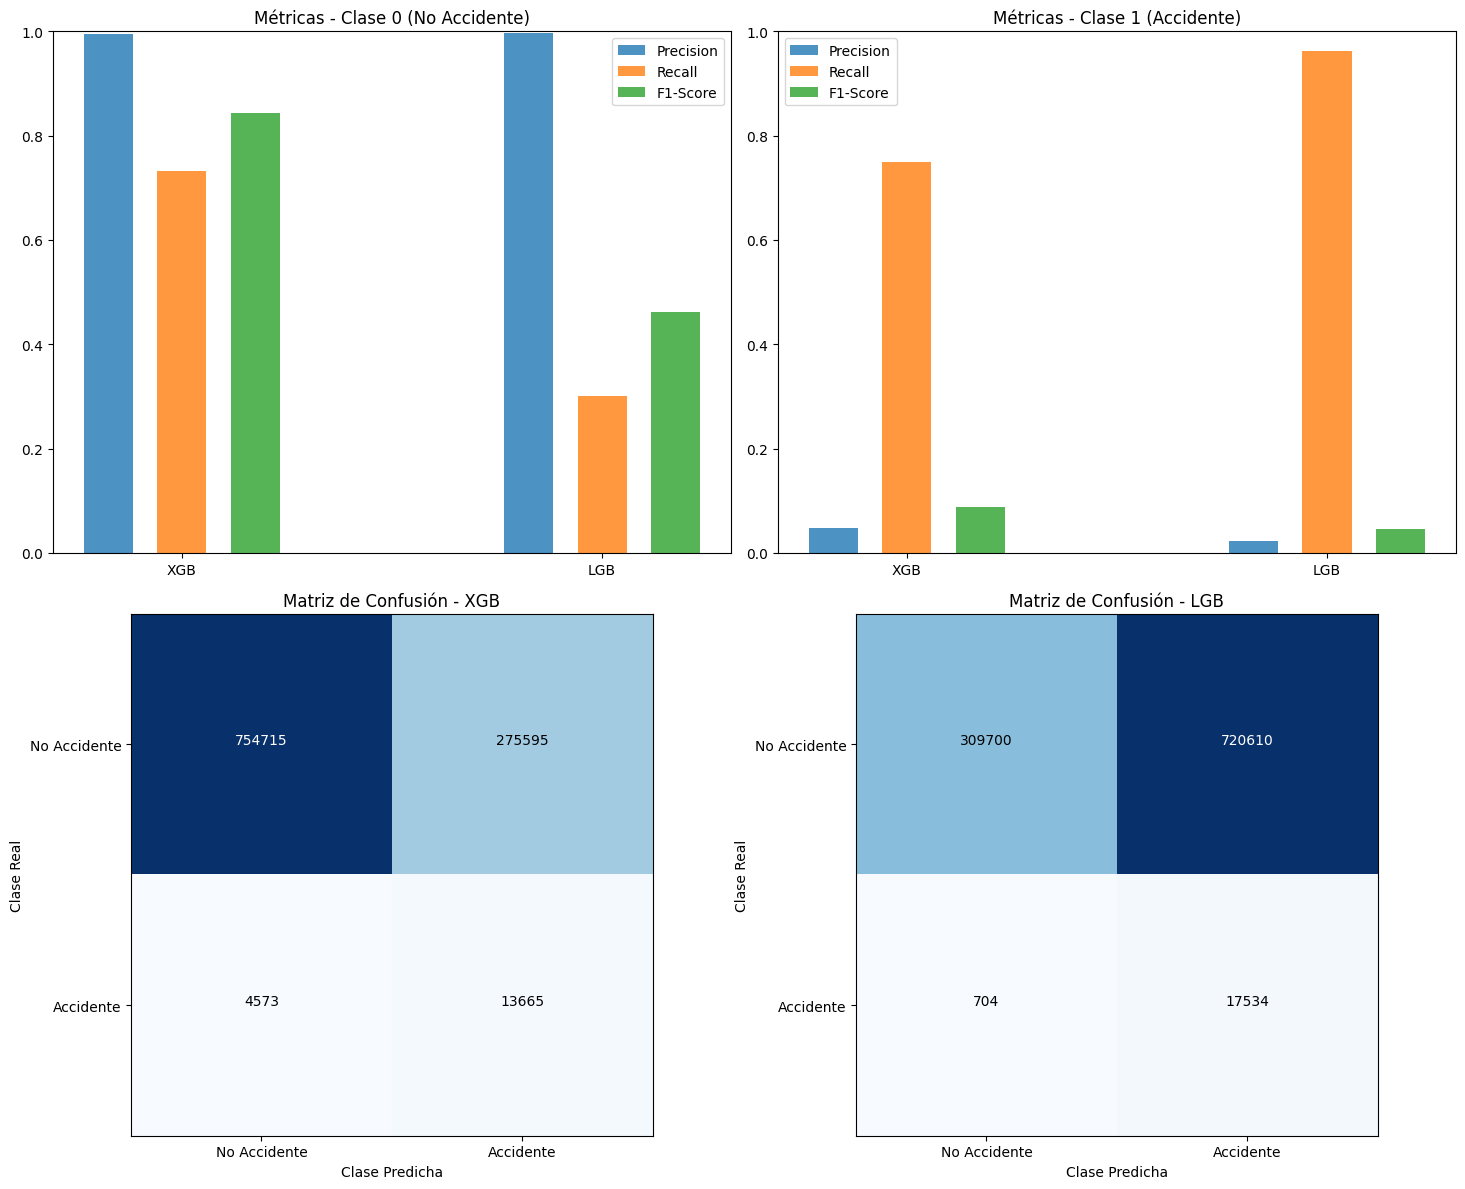

🎯 Importancia de características:

XGB:
                feature  importance
11           is_weekend    0.323767
9                  hour    0.248997
5           dia_festivo    0.121249
10          day_of_week    0.060514
6                  year    0.056558
7                 month    0.046479
0            cluster_id    0.034362
1   temperature_2m (°C)    0.024943
4                Fiesta    0.021764
8                   day    0.021543

LGB:
                  feature  importance
9                    hour          15
6                    year           8
7                   month           3
11             is_weekend           2
4                  Fiesta           1
5             dia_festivo           1
1     temperature_2m (°C)           0
0              cluster_id           0
3   wind_speed_10m (km/h)           0
2      precipitation (mm)           0
🎯 Optimizando threshold para xgb...
Threshold optimizado: 0.0703
Resultados con threshold optimizado:
Clase 1 - Precision: 0.0200, Recall: 0

In [ ]:


class AccidentPredictionPipeline:
    def __init__(self, csv_path):
        """
        Pipeline completo para predicción de accidentes con balanceo híbrido
        """
        self.csv_path = csv_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.results = {}
        
    def load_data(self):
        """Carga y prepara los datos"""
        print("📊 Cargando datos...")
        self.df = pd.read_csv(self.csv_path)
        
        # Convertir time_n a datetime para ordenar cronológicamente
        self.df['time_n'] = pd.to_datetime(self.df['time_n'])
        self.df = self.df.sort_values('time_n').reset_index(drop=True)
        
        print(f"Datos cargados: {self.df.shape[0]} registros, {self.df.shape[1]} columnas")
        print(f"Distribución de clases:")
        print(self.df['accident'].value_counts(normalize=True))
        
    def prepare_features(self):
        """Prepara las features para el modelo"""
        print("🔧 Preparando features...")
        print(f"Eliminando variables no relevantes: ['time_n', 'geometry', 'accident', 'snowfall (cm)']")
        
        # Eliminar columnas no necesarias para el modelo
        feature_cols = [col for col in self.df.columns if col not in ['time_n', 'geometry', 'accident', 'snowfall (cm)']]
        
        X = self.df[feature_cols]
        y = self.df['accident']
        
        print(f"Features utilizadas: {feature_cols}")
        print(f"Total features: {len(feature_cols)}")
        
        # Split temporal: 70% entrenamiento, 30% test
        # Usar los últimos registros como test para simular predicción futura
        split_idx = int(len(self.df) * 0.7)
        
        self.X_train = X.iloc[:split_idx]
        self.X_test = X.iloc[split_idx:]
        self.y_train = y.iloc[:split_idx]
        self.y_test = y.iloc[split_idx:]
        
        print(f"Training set: {self.X_train.shape}")
        print(f"Test set: {self.X_test.shape}")
        print(f"Distribución train - Clase 0: {(self.y_train==0).sum()}, Clase 1: {(self.y_train==1).sum()}")
        print(f"Distribución test - Clase 0: {(self.y_test==0).sum()}, Clase 1: {(self.y_test==1).sum()}")
        
    def apply_hybrid_balancing(self, target_ratio=0.15):
        """
        Aplica estrategia de balanceo híbrido para alcanzar el ratio objetivo
        Aumentamos el ratio objetivo para dar más peso a la clase minoritaria
        """
        print(f"⚖️ Aplicando balanceo híbrido para alcanzar {target_ratio*100}% de clase minoritaria...")
        
        # Calcular la distribución actual
        current_minority = self.y_train.sum()
        current_majority = len(self.y_train) - current_minority
        
        print(f"Distribución original: Mayoría={current_majority}, Minoría={current_minority}")
        
        # Calcular cuántas muestras necesitamos para llegar al 10%
        # Si queremos 10% de minoritaria, entonces 90% será mayoría
        # minority / (minority + majority) = 0.1
        # minority = 0.1 * (minority + majority)
        # minority = 0.1 * minority + 0.1 * majority
        # 0.9 * minority = 0.1 * majority
        # minority = (0.1/0.9) * majority
        
        target_minority = int(current_majority * (target_ratio / (1 - target_ratio)))
        
        print(f"Objetivo: Mayoría={current_majority}, Minoría={target_minority}")
        
        # Estrategia híbrida
        strategies = {}
        
        # 1. SMOTE + Tomek Links
        smote_tomek = SMOTETomek(
            smote=SMOTE(sampling_strategy=target_minority/current_majority, random_state=42),
            tomek=TomekLinks(sampling_strategy='majority'),
            random_state=42
        )
        
        # 2. SMOTE + Edited Nearest Neighbours
        smote_enn = SMOTEENN(
            smote=SMOTE(sampling_strategy=target_minority/current_majority, random_state=42),
            enn=EditedNearestNeighbours(sampling_strategy='majority'),
            random_state=42
        )
        
        # 3. Oversampling + Undersampling manual
        # Primero oversample la minoría
        ros = RandomOverSampler(sampling_strategy=target_minority/current_majority, random_state=42)
        X_over, y_over = ros.fit_resample(self.X_train, self.y_train)
        
        # Luego undersample la mayoría si es necesario
        majority_after_over = len(y_over) - target_minority
        if majority_after_over > current_majority:
            rus = RandomUnderSampler(sampling_strategy={0: current_majority, 1: target_minority}, random_state=42)
            X_hybrid, y_hybrid = rus.fit_resample(X_over, y_over)
        else:
            X_hybrid, y_hybrid = X_over, y_over
        
        strategies['smote_tomek'] = smote_tomek.fit_resample(self.X_train, self.y_train)
        strategies['smote_enn'] = smote_enn.fit_resample(self.X_train, self.y_train)
        strategies['hybrid_manual'] = (X_hybrid, y_hybrid)
        
        # Mostrar resultados de cada estrategia
        print("\n📈 Resultados del balanceo:")
        for name, (X_balanced, y_balanced) in strategies.items():
            counter = Counter(y_balanced)
            minority_pct = counter[1] / len(y_balanced) * 100
            print(f"{name}: Mayoría={counter[0]}, Minoría={counter[1]} ({minority_pct:.1f}%)")
        
        # Seleccionar la estrategia que más se acerque al objetivo
        best_strategy = 'hybrid_manual'  # Por defecto
        best_diff = float('inf')
        
        for name, (X_balanced, y_balanced) in strategies.items():
            counter = Counter(y_balanced)
            current_pct = counter[1] / len(y_balanced)
            diff = abs(current_pct - target_ratio)
            if diff < best_diff:
                best_diff = diff
                best_strategy = name
        
        print(f"\n🎯 Mejor estrategia: {best_strategy}")
        self.X_train_balanced, self.y_train_balanced = strategies[best_strategy]
        
        return best_strategy
        
    def train_models(self):
        """Entrena modelos XGBoost y LightGBM"""
        print("🚀 Entrenando modelos...")
        
        # Calcular scale_pos_weight para modelos
        neg_count = (self.y_train_balanced == 0).sum()
        pos_count = (self.y_train_balanced == 1).sum()
        scale_pos_weight = neg_count / pos_count
        
        print(f"Scale pos weight calculado: {scale_pos_weight:.2f}")
        
        # Parámetros optimizados para recall con class_weight
        xgb_params = {
            'n_estimators': 300,
            'max_depth': 8,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'eval_metric': 'logloss',
            'early_stopping_rounds': 15,
            'min_child_weight': 1,
            'reg_alpha': 0.1,
            'reg_lambda': 0.1
        }
        
        lgb_params = {
            'n_estimators': 300,
            'max_depth': 8,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'class_weight': 'balanced',
            'random_state': 42,
            'verbose': -1,
            'early_stopping_rounds': 15,
            'min_child_samples': 20,
            'reg_alpha': 0.1,
            'reg_lambda': 0.1,
            'is_unbalance': True
        }
        
        # Entrenar XGBoost
        print("Entrenando XGBoost...")
        self.models['xgb'] = xgb.XGBClassifier(**xgb_params)
        self.models['xgb'].fit(
            self.X_train_balanced, 
            self.y_train_balanced,
            eval_set=[(self.X_test, self.y_test)],
            verbose=False
        )
        
        # Entrenar LightGBM
        print("Entrenando LightGBM...")
        self.models['lgb'] = lgb.LGBMClassifier(**lgb_params)
        self.models['lgb'].fit(
            self.X_train_balanced, 
            self.y_train_balanced,
            eval_set=[(self.X_test, self.y_test)]
        )
        
    def evaluate_models(self):
        """Evalúa los modelos y calcula métricas"""
        print("📊 Evaluando modelos...")
        
        for model_name, model in self.models.items():
            print(f"\n🔍 Evaluando {model_name.upper()}:")
            
            # Predicciones
            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)[:, 1]
            
            # Métricas básicas
            report = classification_report(self.y_test, y_pred, output_dict=True)
            cm = confusion_matrix(self.y_test, y_pred)
            auc_score = roc_auc_score(self.y_test, y_pred_proba)
            
            # Almacenar resultados
            self.results[model_name] = {
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'classification_report': report,
                'confusion_matrix': cm,
                'auc_score': auc_score
            }
            
            # Mostrar métricas importantes
            print(f"AUC Score: {auc_score:.4f}")
            print(f"Clase 0 (No accidente) - Precision: {report['0']['precision']:.4f}, Recall: {report['0']['recall']:.4f}")
            print(f"Clase 1 (Accidente) - Precision: {report['1']['precision']:.4f}, Recall: {report['1']['recall']:.4f}")
            print(f"F1-Score macro: {report['macro avg']['f1-score']:.4f}")
            
            # Matriz de confusión
            print(f"Matriz de confusión:")
            print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
            print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")
    
    def plot_results(self):
        """Visualiza los resultados"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Gráfico 1: Comparación de métricas
        metrics = ['precision', 'recall', 'f1-score']
        models = list(self.results.keys())
        
        class_0_metrics = {metric: [self.results[model]['classification_report']['0'][metric] for model in models] 
                          for metric in metrics}
        class_1_metrics = {metric: [self.results[model]['classification_report']['1'][metric] for model in models] 
                          for metric in metrics}
        
        x = np.arange(len(models))
        width = 0.35
        
        # Clase 0
        axes[0,0].bar(x - width/2, class_0_metrics['precision'], width/3, label='Precision', alpha=0.8)
        axes[0,0].bar(x, class_0_metrics['recall'], width/3, label='Recall', alpha=0.8)
        axes[0,0].bar(x + width/2, class_0_metrics['f1-score'], width/3, label='F1-Score', alpha=0.8)
        axes[0,0].set_title('Métricas - Clase 0 (No Accidente)')
        axes[0,0].set_xticks(x)
        axes[0,0].set_xticklabels([m.upper() for m in models])
        axes[0,0].legend()
        axes[0,0].set_ylim(0, 1)
        
        # Clase 1
        axes[0,1].bar(x - width/2, class_1_metrics['precision'], width/3, label='Precision', alpha=0.8)
        axes[0,1].bar(x, class_1_metrics['recall'], width/3, label='Recall', alpha=0.8)
        axes[0,1].bar(x + width/2, class_1_metrics['f1-score'], width/3, label='F1-Score', alpha=0.8)
        axes[0,1].set_title('Métricas - Clase 1 (Accidente)')
        axes[0,1].set_xticks(x)
        axes[0,1].set_xticklabels([m.upper() for m in models])
        axes[0,1].legend()
        axes[0,1].set_ylim(0, 1)
        
        # Matriz de confusión para cada modelo
        for i, (model_name, results) in enumerate(self.results.items()):
            ax = axes[1, i]
            cm = results['confusion_matrix']
            im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            ax.set_title(f'Matriz de Confusión - {model_name.upper()}')
            
            # Añadir números
            thresh = cm.max() / 2.
            for j in range(cm.shape[0]):
                for k in range(cm.shape[1]):
                    ax.text(k, j, format(cm[j, k], 'd'),
                           horizontalalignment="center",
                           color="white" if cm[j, k] > thresh else "black")
            
            ax.set_ylabel('Clase Real')
            ax.set_xlabel('Clase Predicha')
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(['No Accidente', 'Accidente'])
            ax.set_yticklabels(['No Accidente', 'Accidente'])
        
        plt.tight_layout()
        plt.show()
        
    def get_feature_importance(self):
        """Obtiene la importancia de las características"""
        print("🎯 Importancia de características:")
        
        feature_names = self.X_train.columns
        
        for model_name, model in self.models.items():
            print(f"\n{model_name.upper()}:")
            
            if hasattr(model, 'feature_importances_'):
                importance = model.feature_importances_
                feature_importance = pd.DataFrame({
                    'feature': feature_names,
                    'importance': importance
                }).sort_values('importance', ascending=False)
                
                print(feature_importance.head(10))
                
    def optimize_threshold(self, model_name='xgb'):
        """Optimiza el threshold para maximizar recall manteniendo precisión aceptable"""
        print(f"🎯 Optimizando threshold para {model_name}...")
        
        y_proba = self.results[model_name]['probabilities']
        
        # Calcular precision-recall para diferentes thresholds
        precision, recall, thresholds = precision_recall_curve(self.y_test, y_proba)
        
        # Estrategia más agresiva: encontrar threshold que maximice recall con precision > 0.02
        best_threshold = 0.5
        best_recall = 0
        min_precision = 0.02  # Precision mínima más baja para priorizar recall
        
        for i, (p, r, t) in enumerate(zip(precision[:-1], recall[:-1], thresholds)):
            if p >= min_precision and r > best_recall:
                best_recall = r
                best_threshold = t
        
        # Si no encontramos ninguno, usar el que maximice F1 con recall > 0.1
        if best_recall < 0.1:
            f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
            best_idx = np.argmax(f1_scores[recall[:-1] > 0.05])  # Solo considerar recalls > 5%
            best_threshold = thresholds[best_idx]
            best_recall = recall[best_idx]
        
        # Aplicar el mejor threshold
        y_pred_optimized = (y_proba >= best_threshold).astype(int)
        
        print(f"Threshold optimizado: {best_threshold:.4f}")
        print(f"Resultados con threshold optimizado:")
        
        report_opt = classification_report(self.y_test, y_pred_optimized, output_dict=True)
        cm_opt = confusion_matrix(self.y_test, y_pred_optimized)
        
        print(f"Clase 1 - Precision: {report_opt['1']['precision']:.4f}, Recall: {report_opt['1']['recall']:.4f}")
        print(f"Clase 1 - F1-Score: {report_opt['1']['f1-score']:.4f}")
        print(f"Matriz de confusión optimizada:")
        print(f"TN: {cm_opt[0,0]}, FP: {cm_opt[0,1]}")
        print(f"FN: {cm_opt[1,0]}, TP: {cm_opt[1,1]}")
        
        return best_threshold
        
    def run_complete_pipeline(self):
        """Ejecuta el pipeline completo"""
        print("🚀 Iniciando pipeline completo de predicción de accidentes")
        print("="*60)
        
        # 1. Cargar datos
        self.load_data()
        
        # 2. Preparar features
        self.prepare_features()
        
        # 3. Aplicar balanceo híbrido con ratio más agresivo
        balancing_strategy = self.apply_hybrid_balancing(target_ratio=0.15)
        
        # 4. Entrenar modelos
        self.train_models()
        
        # 5. Evaluar modelos
        self.evaluate_models()
        
        # 6. Visualizar resultados
        self.plot_results()
        
        # 7. Importancia de características
        self.get_feature_importance()
        
        # 8. Optimizar threshold
        for model_name in self.models.keys():
            self.optimize_threshold(model_name)
        
        print("\n✅ Pipeline completado exitosamente!")
        
        # Resumen final
        print("\n" + "="*60)
        print("📊 RESUMEN FINAL:")
        print("="*60)
        print("⚠️  NOTA: Si el recall sigue siendo muy bajo, considera:")
        print("   - Aumentar más el ratio de balanceo (0.2-0.3)")
        print("   - Usar métricas de evaluación diferentes (ej: F2-score)")
        print("   - Revisar la calidad de las features")
        
        for model_name, results in self.results.items():
            report = results['classification_report']
            print(f"\n{model_name.upper()}:")
            print(f"  AUC: {results['auc_score']:.4f}")
            print(f"  Recall Clase 1 (Accidentes): {report['1']['recall']:.4f}")
            print(f"  Precision Clase 1: {report['1']['precision']:.4f}")
            print(f"  F1-Score Clase 1: {report['1']['f1-score']:.4f}")
            
            # Calcular y mostrar el número real de accidentes detectados
            cm = results['confusion_matrix']
            tp = cm[1,1]
            fn = cm[1,0]
            total_accidents = tp + fn
            detection_rate = tp / total_accidents if total_accidents > 0 else 0
            
            print(f"  Accidentes detectados: {tp} de {total_accidents} ({detection_rate:.1%})")
            print(f"  Falsas alarmas: {cm[0,1]}")
            
        # Recomendación final
        best_model = max(self.results.keys(), 
                        key=lambda x: self.results[x]['classification_report']['1']['recall'])
        print(f"\n🏆 Mejor modelo por recall: {best_model.upper()}")
        
        return best_model

# Uso del pipeline
if __name__ == "__main__":
    # Inicializar y ejecutar pipeline
    pipeline = AccidentPredictionPipeline("../data/processed/df_ready_model.csv")
    pipeline.run_complete_pipeline()